In [143]:
import requests
import pandas as pd 
from tqdm.auto import tqdm

# http://localhost:8080 ...
def emb_local(text):
    r = requests.post(
        "http://localhost:8080/embed", 
        data='{"inputs":"%s"}' % text,
        headers={'Content-Type': 'application/json'}
    )
    try:
        r = r.json()
    except:
        r = None
    return r

In [134]:
import pandas as pd 
from sklearn.metrics import roc_auc_score, f1_score
import seaborn as sns

In [43]:
t = pd.read_json('cache/gpt_training/gpt3-training-full__2013-2017.jsonl', lines=True)

In [26]:
print(t['prompt'].iloc[3])

Proposal description:

```Liquor License Transfer - 65 Post Street. Resolution determining that the transfer of a Type 48 on-sale general public premises license from 86-2nd Street to 65 Post Street (District 3) to M&M Group Assets, Inc. dba Dada Bar and Lounge, will serve the public convenience or necessity of the City and County of San Francisco in accordance with California Business and Professions Code, Section 23958.4, and recommending that the California Department of Alcoholic Beverage Control impose conditions on the issuance of the license.```

Introduced by 1 speakers in the meeting for 0.1 minutes:

```Madam Clerk, call item 43 and 44 together, please.```

0 members of the public spoke.

Is this newsworthy?


# Load Scored Data 

In [209]:
scored_data = pd.read_json('cache/2024-03-25__retrieve-examples-for-demo/sample-gpt3-scored-data__prior-meetings.jsonl', lines=True)
(
    scored_data[['meeting text', 'label', 'lm_y_prob']]
        .sort_values('lm_y_prob', ascending=False)
        .head(5)
)

,meeting text,label,lm_y_prob
983,"Appointments, Immigrant Rights Commission - Sa...",0,0.999908
79,Urging SFMTA to Prioritize and Expedite Vision...,0,0.999893
1311,Central Market Community Benefit District - An...,0,0.999853
13,Planning Code - Exemption from Neighborhood No...,0,0.999844
2238,Resolution of Intention to Amend Management Pl...,0,0.999836


<Axes: >

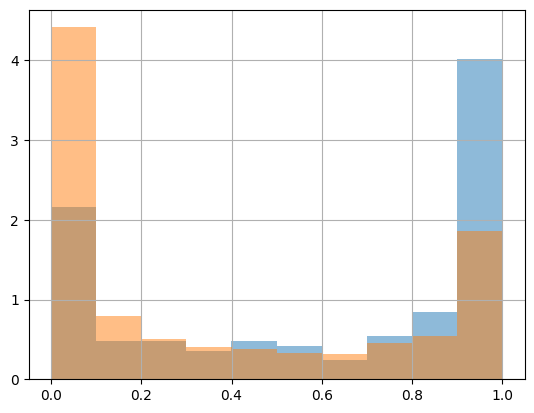

In [87]:
import matplotlib.pyplot as plt 

f, ax = plt.subplots( 1, 1)
scored_data.loc[lambda df: df['label'] == 1]['lm_y_prob'].hist( ax=ax, alpha=.5, density=True)
scored_data.loc[lambda df: df['label'] == 0]['lm_y_prob'].hist( ax=ax, alpha=.5, density=True)

In [108]:
scored_data['public_comment_num_speakers'].value_counts()

public_comment_num_speakers
0     2387
1       73
2       20
3        6
7        2
6        1
25       1
17       1
Name: count, dtype: int64

# Link News Coverage/ Find Previous News Coverage

In [142]:
# previous news coverage
scored_data['news_coverage_dates'].str.len().value_counts()
scored_data.loc[lambda df: df['label'] == 1]['news_coverage_dates'].str.len().value_counts()

news_coverage_dates
1    114
2     32
3     16
4      8
5      4
6      3
7      1
9      1
8      1
Name: count, dtype: int64

# Public Comment

In [ ]:
public_speaker_embs_df = pd.read_json('cache/2024-03-25__retrieve-examples-for-demo/public-speaker-embeddings.jsonl', lines=True)
public_speaker_embs_df = (
    public_speaker_embs_df
         .loc[lambda df: df['transcribed_text'].str.split().str.len() > 10]
         .dropna()
)

In [216]:
meeting_embs = np.array(scored_data[['meeting text', 'embs']].dropna()['embs'].tolist())

In [234]:
public_speaker_embs = np.array(public_speaker_embs_df['embs'].tolist())

In [242]:
meeting2public_speaker_sim_df = pd.DataFrame(
    cosine_similarity(meeting_embs, public_speaker_embs), 
    index=scored_data[['meeting text', 'embs']].dropna().index, 
    columns=public_speaker_embs_df.index
)

In [260]:
high_matches = (
    meeting2public_speaker_sim_df
         .unstack().to_frame('sim')
         .reset_index().rename(columns={'level_0': 'public_speaker_idx', 'level_1': 'meeting_idx'})
         .loc[lambda df: df['sim'] > .65]
)

In [263]:
public_speaker_embs_df.loc[125331]['transcribed_text']

"I am here also to provide my support with the child resolution and we are looking forward to work with ECE, so important for San Francisco children's community and also as a mother that advocate on child care."

In [266]:
scored_data['meeting text']

0       Concurring in Proclamation of Local Emergency ...
1       Concurring in Actions to Meet Local Emergency ...
2       Committee of the Whole - Proclamation of Local...
3       Proclamation of Local Emergency - Drug Overdos...
4       Hearing - Committee of the Whole - Proclamatio...
                              ...                        
2486    Urging the Planning Department to Prioritize F...
2487    Concurring in Actions to Meet Local Emergency ...
2488    Closed Session - Existing Litigation - PG&E Po...
2489    Findings to Allow Teleconferenced Meetings Dur...
2490    Reappointment, Bicycle Advisory Committee - Be...
Name: meeting text, Length: 2491, dtype: object

In [268]:
public_speaker_embs_df['transcribed_text']

0         Any public speaker using translation assistanc...
1         The President or the Board may limit the total...
3         And finally, if by majority vote the Board cho...
5         And I'll just reiterate the last thing that ou...
11        After 28 years I spend in this city, in that p...
                                ...                        
125550    I think respect is earned and respect for the ...
125551    We're trying to make it a cleaner, safer, more...
125552    And that includes the high tech guys that are ...
125556    So please keep that in mind when you're going ...
125569    Madam Clerk, could you please read the adoptio...
Name: transcribed_text, Length: 42264, dtype: object

In [295]:
high_matches_df = (
    high_matches
         .merge(public_speaker_embs_df[['transcribed_text']], right_index=True, left_on='public_speaker_idx')
         .merge(scored_data[['meeting text']], right_index=True, left_on='meeting_idx')
         .merge(
            scored_data[['File #']], 
            right_index=True,
            left_on='meeting_idx'
        )
        .drop(['sim', 'public_speaker_idx', 'meeting_idx'], axis=1)
        .rename(columns={'transcribed_text': 'public_comment'})
)

In [ ]:
'nomic-ai/nomic-embed-text-v1'

In [303]:
public_comment_aggregated = (
    high_matches_df
         .groupby('File #')['public_comment']
         .aggregate(list)
         .to_frame()
)

# Get Matched Negative Examples

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
import numpy as np 
tqdm.pandas()

In [153]:
meeting_text_embs = scored_data['meeting text'].progress_apply(emb_local)

  0%|          | 0/2491 [00:00<?, ?it/s]

In [313]:
# scored_data['public_comment'] = scored_data.merge(public_comment_aggregated, left_on='File #', right_index=True, how='left')['public_comment']
scored_data['embs'] = meeting_text_embs.str.get(0)

In [314]:
neg_examples = (
    scored_data
         .drop_duplicates('meeting text')
         .loc[lambda df: df['embs'].notnull()]
         .loc[lambda df: df['label'] == 0]
)
pos_examples = (
    scored_data
         .drop_duplicates('meeting text')
         .loc[lambda df: df['embs'].notnull()]
         .loc[lambda df: df['label'] == 1]    
)

In [315]:
neg_examples_embs = np.array(neg_examples['embs'].tolist())
pos_examples_embs = np.array(pos_examples['embs'].tolist())

In [320]:
cos_sims = cosine_similarity(pos_examples_embs, neg_examples_embs)
cos_sims_df = pd.DataFrame(cos_sims, index=pos_examples.index, columns=neg_examples.index)

In [337]:
pairs = list(cos_sims_df.idxmax(axis=1).to_dict().items())

In [358]:
final_matching_df = pd.read_csv('cache/final-matching-articles-and-meetings.csv', index_col=0)

In [459]:
from copy import deepcopy
neg_label_map = {
    'label': 'Was article written?',
    'lm_y_prob': 'Model Prediction', 
    'Title': 'Policy Summary',
    'Name': 'Policy Title',
    'date': 'Meeting date',
    'transcribed_time_in_minutes': 'Time spent on policy (minutes)',
    'transcribed_num_speakers': '# assembly people talked',    
    'num_meetings': '# prior meetings this policy was discussed in',
    'prior_news_coverage': 'Prior News Coverage', 
    'public_comment': 'Public Commenters',
    'transcribed_text': 'Speaker Comments',    
}
pos_label_map = {
    'label': 'Was article written?',
    'lm_y_prob': 'Model Prediction', 
    'Title': 'Policy Summary',
    'Name': 'Policy Title',
    'summary_text': 'News Article Text (Summary)',
    'date': 'Meeting date',
    'transcribed_time_in_minutes': 'Time spent on policy (minutes)',
    'transcribed_num_speakers': '# assembly people talked',
    'num_meetings': '# prior meetings this policy was discussed in',
    'prior_news_coverage': 'Prior News Coverage', 
    'public_comment': 'Public Commenters',
    'transcribed_text': 'Speaker Comments',
}

In [467]:
def format_output(inp):
    output = []
    for k, v in inp.items():
        if isinstance(v, list):
            v = '\n'.join(v)
        output.append(f'{k}\n{v}')
    return '\n\n'.join(output)

In [582]:
idx = 78
pos_idx, neg_idx = pairs[idx]
pos_name = pos_examples.loc[pos_idx]['Name']
neg_name = neg_examples.loc[neg_idx]['Name']
print(pos_name)
print(neg_name)

Urging the City and County of San Francisco to Revise Shelter-in-Place Hotels' Standard Agreements with Existing Owners to Include an Option to Purchase the Hotels and/or a Long-Term Lease
Urging President Biden to Extend Funding Assistance from FEMA to Maintain Non-Congregate Shelter In Place Hotels Through the Year of 2022


In [575]:
# pos_name = pos_examples.loc[lambda df: df['Name'].str.contains('bicycle')]['Name'].iloc[0]

In [576]:
p_ex_output = (
    pos_examples
         .pipe(lambda df: 
               df.merge(final_matching_df[['File #', 'summary_text']], on='File #')
          )
         .loc[lambda df: df['Name'] == pos_name]
         .iloc[0]
         .rename(pos_label_map)
         [pos_label_map.values()]
         .to_dict()
)

In [577]:
p_ex_output

{'Was article written?': 1,
 'Model Prediction': 0.8059121721,
 'Policy Summary': 'Resolution urging the Board of Supervisors to save San Francisco Unified School District (SFUSD) Senior Class of 2021 activities by providing support, funds and/or City resources; and, if allowable under current health orders, to be made available to SFUSD Seniors for senior specific activities.',
 'Policy Title': 'Urging the City and County of San Francisco to Support and/or Fund SFUSD Class of 2021 Senior Activities',
 'News Article Text (Summary)': 'With our return date less than three weeks away, the reasonable solution is for SFUSD and the Board of Ed to work with the Board of Supervisors to open more centers for the youth of its many educator parents.\n\nCalifornia is a leader on gun violence prevention laws. We trust our state legislators to ensure our safety by passing common sense gun laws. However, a rising issue threatens to erase our progress so far: ghost guns.',
 'Meeting date': Timestamp('

In [570]:
import pyperclip
pyperclip.copy(format_output(p_ex_output))

In [583]:
n_ex_output = (
    neg_examples
         .loc[neg_idx]
         .rename(neg_label_map)
         [neg_label_map.values()]
         .to_dict()
)

In [586]:
pyperclip.copy(format_output(n_ex_output))

In [585]:
n_ex_output

{'Was article written?': 0,
 'Model Prediction': 0.2654761846,
 'Policy Summary': 'Resolution urging President Joseph R. Biden, in coordination with the Department of Homeland Security, to direct the Federal Emergency Management Agency (FEMA) to sustain public assistance funding to the City and County of San Francisco through 2022 for the purpose of advancing and maintaining the Shelter-In-Place Hotel alternative housing program to mitigate the spread of COVID-19 among vulnerable homeless populations.',
 'Policy Title': 'Urging President Biden to Extend Funding Assistance from FEMA to Maintain Non-Congregate Shelter In Place Hotels Through the Year of 2022',
 'Meeting date': Timestamp('2021-10-05 00:00:00'),
 'Time spent on policy (minutes)': 0.31435,
 '# assembly people talked': 2,
 '# prior meetings this policy was discussed in': 10,
 'Prior News Coverage': 0,
 'Public Commenters': ["I'm encouraging this board to pass this resolution and continue their support to keep people in their